# Protocolo de Transmisión de Datos Acústica

**Facultad de Ingeniería - UNAM**

**Asignatura:** Procesamiento Digital de Señales

**Semestre 2026-2**

**Grupo 2**

**Proyecto Final**

**Integrantes:**

| Nombre | |
|---|---|
| Ángel Jesús Pérez Álvarez | |
| Fredy Iker Patiño Mendoza | |
| José Antonio Aguilar Lugo | |
| Daniel Orlando Jiménez Chávez | |

---

## Descripción del proyecto

Diseño e implementación de un sistema emisor-receptor capaz de transmitir cadenas de texto entre dos computadoras utilizando únicamente audio en formato `.wav`, tomando como base lo desarrollado en la Práctica No. 3.

El sistema codifica cada carácter ASCII como un patrón de presencia/ausencia de frecuencias (representación binaria de 8 bits), agrupa hasta **33 caracteres por chunk** y los transmite como señal de audio. El receptor recupera el mensaje original aplicando un banco de filtros y el algoritmo de Goertzel.

---

## Especificaciones técnicas

| Parámetro | Valor |
|---|---|
| Frecuencia de muestreo (Fs) | 8 000 Hz |
| Muestras por chunk (N) | 4 000 |
| Resolución frecuencial (Δf) | 2 Hz/bin |
| Duración por chunk | 0.5 s |
| Caracteres por chunk | 33 |
| Bits por carácter | 8 |
| Frecuencias totales por chunk | 264 (33 slots × 8 bits) |
| Portadora primer slot | 500 Hz |
| Portadora último slot | 3 700 Hz |
| Frecuencia máxima de datos | 3 770 Hz |
| Separación entre bits | 10 Hz |
| Separación entre slots | 100 Hz |
| Codificación | ASCII-256 |
| Algoritmo de detección | Goertzel |

---

## Arquitectura del sistema

```
ENCODER
  Mensaje ASCII
      |
      v
  Codificación binaria (8 bits por carácter)
      |
      v
  Generación de sinusoides (hasta 264 simultáneas por chunk)
      |
      v
  Normalización por chunk
      |
      v
  Archivo WAV (Fs = 8 000 Hz)

DECODER
  Archivo WAV
      |
      v
  Filtro FIR global pasa-banda Parks-McClellan (480–3 790 Hz)
  → Rechaza ruido fuera del rango de datos
      |
      v
  Banco de 264 filtros FIR por bit (f_bit ± 4 Hz c/u)
  → Aisla cada frecuencia antes de la detección
      |
      v
  Algoritmo de Goertzel por bit
  → Magnitud en cada frecuencia objetivo
      |
      v
  Umbral relativo (m / max_slot ≥ umbral)
  → Decisión bit = 1 / bit = 0
      |
      v
  Reconstrucción ASCII → Mensaje recuperado
```

---

## Filtrado FIR Parks-McClellan

El sistema emplea dos capas de filtrado diseñadas con el algoritmo de Parks-McClellan (intercambio de Remez):

**Capa 1 — Filtro global pasa-banda**
Banda de paso 480–3 790 Hz, orden 256, atenuación ≥ 60 dB fuera de banda.
Rechaza componentes de baja frecuencia, ruido ambiental y energía fuera del rango de datos.

**Capa 2 — Banco de 264 filtros por bit**
Cada filtro tiene una banda de paso de ±4 Hz alrededor de su frecuencia objetivo, con 4 Hz de transición y peso 10× en las bandas de rechazo.
Aísla la componente de interés eliminando la interferencia de las otras 263 frecuencias activas simultáneamente.

---

## Tablas de frecuencias

La frecuencia asignada a cada bit se calcula como:

```
f(slot, bit) = 500 + slot × 100 + bit × 10   [Hz]
```

### Primeros 4 slots (ejemplo)

| Slot | Portadora | b0 | b1 | b2 | b3 | b4 | b5 | b6 | b7 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 500 Hz | 500 | 510 | 520 | 530 | 540 | 550 | 560 | 570 |
| 1 | 600 Hz | 600 | 610 | 620 | 630 | 640 | 650 | 660 | 670 |
| 2 | 700 Hz | 700 | 710 | 720 | 730 | 740 | 750 | 760 | 770 |
| 3 | 800 Hz | 800 | 810 | 820 | 830 | 840 | 850 | 860 | 870 |

*Todos los valores en Hz. La tabla completa cubre los slots 0–32 (500–3 700 Hz).*

---

## Código ASCII
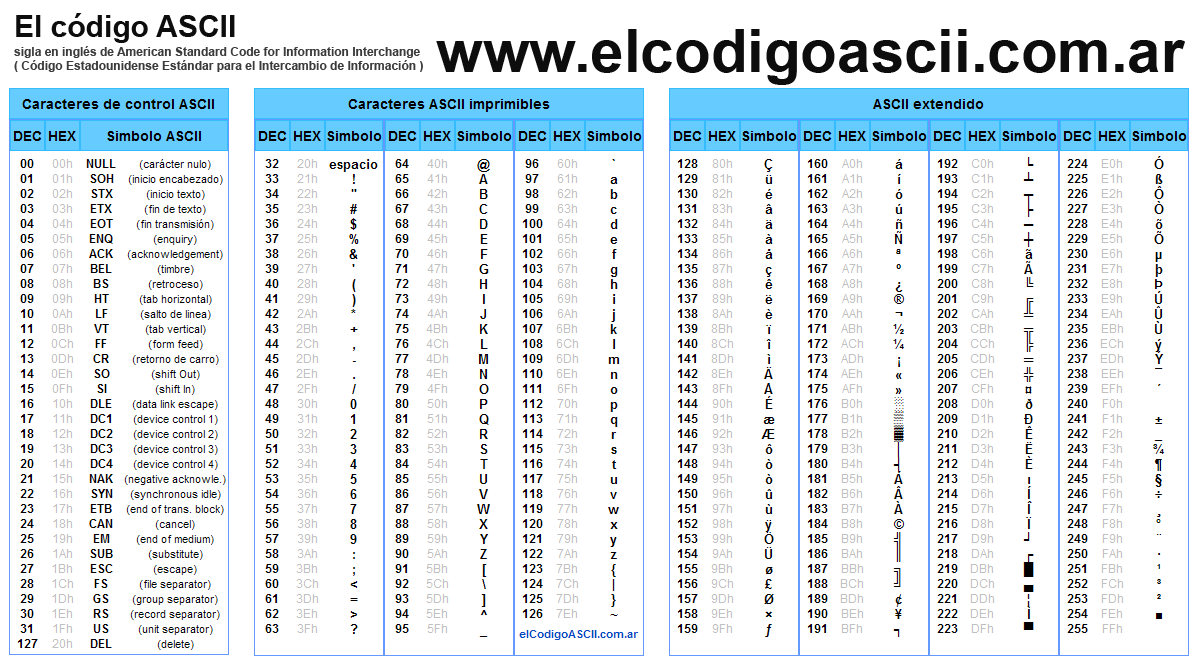

In [1]:
# ============================================================
#  DSP ASCII Transmission System — 33 caracteres por chunk
#  Encoder + Decoder con Parks-McClellan FIR
#  Fs = 8000 Hz | N = 4000 muestras | ASCII-256
#  33 slots x 8 bits = 264 frecuencias por chunk
#  Rango espectral: 500–3970 Hz
#  Filtro paso banda global: 480–3790 Hz (rechaza voz < 500 Hz)
# ============================================================

# !pip install ipywidgets numpy scipy matplotlib

import numpy as np
from scipy.io import wavfile
from scipy.signal import remez, freqz, lfilter, find_peaks
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings, os, base64
warnings.filterwarnings('ignore')
plt.ioff()

# ────────────────────────────────────────────────────────────
#  PARAMETROS GLOBALES
# ────────────────────────────────────────────────────────────

FS         = 8000
N_MUESTRAS = 4000
DELTA_F    = FS / N_MUESTRAS        # 2 Hz/bin
N_BITS     = 8                      # bits por caracter
N_SLOTS    = 33                     # caracteres por chunk (500-3770 Hz, ultimo bit = 3770 Hz)
PASO_BIT   = 10                     # Hz entre bits del mismo slot
PASO_SLOT  = 100                    # Hz entre portadoras de slots
F_INICIO   = 500                    # Hz — portadora del slot 0
UMBRAL_DET = 0.15
FIR_ORDEN  = 128

# Filtro paso banda global
FPB_F_LOW  = 480                    # Hz — inicio banda de paso
FPB_F_HIGH = 3790                   # Hz — fin banda de paso (margen sobre 3770 Hz)
FPB_TRANS  = 60                     # Hz — ancho de banda de transicion
FPB_ORDEN  = 256                    # orden del filtro global

# Portadoras: 500, 600, 700, ..., 3700 Hz  (33 slots, ultimo bit = 3770 Hz)
PORTADORAS = [F_INICIO + s * PASO_SLOT for s in range(N_SLOTS)]

# Frecuencias: slot s, bit b → F_INICIO + s*PASO_SLOT + b*PASO_BIT
FREQS_SLOT_BIT = [
    [PORTADORAS[s] + b * PASO_BIT for b in range(N_BITS)]
    for s in range(N_SLOTS)
]

COLORES_BITS = [
    '#1f77b4', '#d62728', '#2ca02c', '#ff7f0e',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'
]

t_vec = np.arange(N_MUESTRAS) / FS


# ────────────────────────────────────────────────────────────
#  FILTRO PASO BANDA GLOBAL (Parks-McClellan)
# ────────────────────────────────────────────────────────────

def disenar_filtro_global(f_low=FPB_F_LOW, f_high=FPB_F_HIGH,
                           f_trans=FPB_TRANS, orden=FPB_ORDEN):
    """
    Filtro paso banda global Parks-McClellan.
    Rechaza todo lo que este por debajo de f_low (voz humana, ruido grave)
    y por encima de f_high (ruido agudo, aliasing).
    Se aplica UNA VEZ al chunk antes de los filtros por bit.
    """
    nyq     = FS / 2.0
    f_stop1 = max(f_low  - f_trans, 1.0)
    f_stop2 = min(f_high + f_trans, nyq - 1.0)
    bands   = [0, f_stop1, f_low, f_high, f_stop2, nyq]
    weight  = [10, 1, 10]
    try:
        h = remez(orden + 1,
                  [x / nyq for x in bands],
                  [0, 1, 0],
                  weight=weight,
                  fs=2.0)
    except Exception:
        from scipy.signal import firwin
        h = firwin(orden + 1,
                   [max(f_low / nyq, 0.001), min(f_high / nyq, 0.999)],
                   pass_zero=False)
    return h


print('Diseñando filtro paso banda global...')
H_GLOBAL = disenar_filtro_global()
print(f'Filtro global listo — orden {len(H_GLOBAL)-1}')


# ────────────────────────────────────────────────────────────
#  BANCO DE FILTROS POR BIT (Parks-McClellan, 264 filtros)
# ────────────────────────────────────────────────────────────

def disenar_banco_filtros(orden=FIR_ORDEN):
    """
    264 filtros pasa-banda Parks-McClellan, uno por (slot, bit).
    Banda de paso: f_bit ± 4 Hz  |  Transición: 4 Hz
    """
    nyq     = FS / 2.0
    filtros = []
    for s in range(N_SLOTS):
        fila = []
        for b in range(N_BITS):
            f_bit   = FREQS_SLOT_BIT[s][b]
            f_low   = f_bit - 4.0
            f_high  = f_bit + 4.0
            f_stop1 = max(f_low  - 4.0, 1.0)
            f_stop2 = min(f_high + 4.0, nyq - 1.0)
            bands   = [0, f_stop1, f_low, f_high, f_stop2, nyq]
            weight  = [10, 1, 10]
            try:
                h = remez(orden + 1,
                          [x / nyq for x in bands],
                          [0, 1, 0],
                          weight=weight,
                          fs=2.0)
            except Exception:
                from scipy.signal import firwin
                h = firwin(orden + 1,
                           [max(f_low / nyq, 0.001),
                            min(f_high / nyq, 0.999)],
                           pass_zero=False)
            fila.append(h)
        filtros.append(fila)
    return filtros


print('Diseñando banco de filtros por bit (264 filtros)...')
BANCO_FILTROS = disenar_banco_filtros()
print('Banco de filtros listo.')


# ────────────────────────────────────────────────────────────
#  ENCODER
# ────────────────────────────────────────────────────────────

def char_a_bits(c):
    val = ord(c) & 0xFF
    return [(val >> i) & 1 for i in range(N_BITS)]


def bits_a_char(bits):
    val = sum(b << i for i, b in enumerate(bits))
    try:
        return chr(val)
    except Exception:
        return '?'


def codificar_mensaje(mensaje):
    """
    Divide el mensaje en grupos de N_SLOTS chars.
    Aplica el filtro paso banda global al chunk codificado.
    Retorna (senal, grupos, bits_por_chunk).
    """
    resto = len(mensaje) % N_SLOTS
    if resto:
        mensaje = mensaje + ' ' * (N_SLOTS - resto)

    grupos      = [mensaje[i:i + N_SLOTS]
                   for i in range(0, len(mensaje), N_SLOTS)]
    segmentos   = []
    bits_chunks = []

    for grupo in grupos:
        chunk     = np.zeros(N_MUESTRAS)
        bits_fila = []
        for s, char in enumerate(grupo):
            bits = char_a_bits(char)
            bits_fila.append(bits)
            for b, bit_val in enumerate(bits):
                if bit_val:
                    chunk += np.sin(2 * np.pi * FREQS_SLOT_BIT[s][b] * t_vec)

        # No se aplica filtro global en el encoder:
        # las sinusoides generadas ya caen exactamente en la banda de datos.
        # El filtro global se aplica solo en el decoder para rechazar ruido.
        pico = np.max(np.abs(chunk))
        if pico > 0:
            chunk /= pico
        segmentos.append(chunk)
        bits_chunks.append(bits_fila)

    senal = np.concatenate(segmentos) if segmentos else np.array([])
    return senal, grupos, bits_chunks


def guardar_wav(senal, ruta):
    pico = np.max(np.abs(senal))
    if pico > 0:
        senal = senal / pico
    wavfile.write(ruta, FS, (senal * 32767).astype(np.int16))


# ────────────────────────────────────────────────────────────
#  GOERTZEL
# ────────────────────────────────────────────────────────────

def goertzel(senal, freq_obj, fs=FS):
    Ns   = len(senal)
    k    = round(freq_obj * Ns / fs)
    w    = 2 * np.pi * k / Ns
    coef = 2 * np.cos(w)
    s1 = s2 = 0.0
    for x in senal:
        s      = float(x) + coef * s1 - s2
        s2, s1 = s1, s
    pot = s2**2 + s1**2 - np.cos(w) * s1 * s2
    return np.sqrt(max(pot, 0.0)) / Ns


# ────────────────────────────────────────────────────────────
#  DECODER
# ────────────────────────────────────────────────────────────

def decodificar_chunk(chunk, metodo='Goertzel', umbral=UMBRAL_DET):
    """
    1. Aplica filtro paso banda global con filtfilt (latencia cero,
       sin distorsion de fase) para rechazar ruido y voz fuera de banda.
    2. Para cada (slot, bit): aplica filtro por bit (lfilter) + Goertzel/FFT.
    3. Umbral relativo al maximo del slot.

    filtfilt en el filtro global vs lfilter en filtros por bit:
    - filtfilt: pasa la senal en ambas direcciones, cancela la fase.
      Correcto para el filtro global donde el transitorio de orden 256
      corromperia ~128 muestras al inicio del chunk.
    - lfilter: causal, transitorio breve (orden 128). Aceptable para
      los filtros por bit porque Goertzel promedia sobre toda la senal
      y el transitorio de 64 muestras tiene impacto minimo.
    """
    from scipy.signal import filtfilt as _filtfilt
    chunk_pb = _filtfilt(H_GLOBAL, 1.0, chunk)

    bits_slot = []
    mags_slot = []

    for s in range(N_SLOTS):
        mags_bits = []
        for b in range(N_BITS):
            h       = BANCO_FILTROS[s][b]
            f_bit   = FREQS_SLOT_BIT[s][b]
            chunk_f = lfilter(h, 1.0, chunk_pb)

            if metodo == 'Goertzel':
                mag = goertzel(chunk_f, f_bit)
            else:
                esp  = np.abs(np.fft.rfft(chunk_f)) / N_MUESTRAS
                frqs = np.fft.rfftfreq(N_MUESTRAS, 1.0 / FS)
                idx  = np.argmin(np.abs(frqs - f_bit))
                mag  = esp[idx]
            mags_bits.append(mag)

        max_m = max(mags_bits) if max(mags_bits) > 0 else 1.0
        bits  = [1 if m / max_m >= umbral else 0 for m in mags_bits]
        bits_slot.append(bits)
        mags_slot.append(mags_bits)

    return bits_slot, mags_slot


def decodificar_wav_archivo(ruta, metodo='Goertzel', umbral=UMBRAL_DET):
    """Lee el WAV y decodifica todos los chunks."""
    fs_w, datos = wavfile.read(ruta)
    if datos.ndim == 2:
        datos = datos[:, 0]
    senal = datos.astype(np.float64)
    pico  = np.max(np.abs(senal))
    if pico > 0:
        senal /= pico
    if fs_w != FS:
        n_new = int(len(senal) * FS / fs_w)
        senal = np.interp(np.linspace(0, len(senal) - 1, n_new),
                          np.arange(len(senal)), senal)
        print(f'Resampleado {fs_w} Hz a {FS} Hz.')

    n_chunks    = len(senal) // N_MUESTRAS
    mensaje     = ''
    bits_chunks = []
    mags_chunks = []
    grupos      = []

    for i in range(n_chunks):
        chunk             = senal[i * N_MUESTRAS:(i + 1) * N_MUESTRAS]
        bits_slot, mags_s = decodificar_chunk(chunk, metodo, umbral)
        bits_chunks.append(bits_slot)
        mags_chunks.append(mags_s)
        grupo = ''.join(bits_a_char(bits_slot[s]) for s in range(N_SLOTS))
        grupos.append(grupo)
        mensaje += grupo

    mensaje = mensaje.rstrip(' ')
    if grupos:
        grupos[-1] = grupos[-1].rstrip(' ')

    return mensaje, senal, bits_chunks, mags_chunks, n_chunks, grupos


# ────────────────────────────────────────────────────────────
#  VISUALIZACIONES
# ────────────────────────────────────────────────────────────

def _show(fig):
    display(fig)
    plt.close(fig)


def grafica_1_mapa_codificacion(grupos, bits_chunks):
    n_chunks = len(bits_chunks)
    mat      = np.zeros((n_chunks, N_SLOTS * N_BITS))
    for i, bf in enumerate(bits_chunks):
        for s in range(N_SLOTS):
            for b in range(N_BITS):
                mat[i, s * N_BITS + b] = bf[s][b]

    fig, ax = plt.subplots(figsize=(18, max(3, n_chunks * 0.55 + 1.5)))
    im = ax.imshow(mat, aspect='auto', cmap='Blues',
                   vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks([s * N_BITS for s in range(N_SLOTS)])
    ax.set_xticklabels([f'S{s}\n{PORTADORAS[s]}Hz'
                        for s in range(N_SLOTS)], fontsize=6, rotation=45)
    for s in range(1, N_SLOTS):
        ax.axvline(s * N_BITS - 0.5, color='white', linewidth=0.5, alpha=0.6)
    ax.set_yticks(range(n_chunks))
    ax.set_yticklabels([f'Ch.{i+1}  "{grupos[i][:12]}..."'
                        if len(grupos[i]) > 12
                        else f'Ch.{i+1}  "{grupos[i]}"'
                        for i in range(n_chunks)], fontsize=8)
    ax.set_xlabel('Slot (portadora) -> Bit')
    ax.set_ylabel('Chunk')
    ax.set_title(
        f'Mapa de Codificación Binaria  '
        f'({N_SLOTS} slots x {N_BITS} bits = {N_SLOTS * N_BITS} columnas)',
        fontsize=11)
    plt.colorbar(im, ax=ax, label='Bit activo', shrink=0.6)
    plt.tight_layout()
    return fig


def grafica_2_respuesta_filtros(n_slots_mostrar=4):
    fig, axes = plt.subplots(n_slots_mostrar, N_BITS,
                             figsize=(18, n_slots_mostrar * 2.2),
                             sharex=False, sharey=True)
    for s in range(n_slots_mostrar):
        for b in range(N_BITS):
            h    = BANCO_FILTROS[s][b]
            f_b  = FREQS_SLOT_BIT[s][b]
            w, H = freqz(h, worN=4096, fs=FS)
            H_db = 20 * np.log10(np.abs(H) + 1e-12)
            ax   = axes[s][b]
            ax.plot(w, H_db, color=COLORES_BITS[b], linewidth=0.9)
            ax.axvline(f_b, color='black', linestyle='--',
                       linewidth=0.7, alpha=0.6)
            ax.axhline(-3, color='gray', linestyle=':', linewidth=0.6)
            ax.set_xlim([f_b - 30, f_b + 30])
            ax.set_ylim([-80, 5])
            ax.set_title(f'S{s} b{b}\n{f_b}Hz', fontsize=7, pad=2)
            ax.tick_params(labelsize=6)
            if b == 0:
                ax.set_ylabel(f'Slot {s}\n{PORTADORAS[s]}Hz', fontsize=7)
    fig.suptitle(
        f'Respuesta en Frecuencia Parks-McClellan  '
        f'(primeros {n_slots_mostrar} slots de {N_SLOTS})',
        fontsize=11)
    plt.tight_layout()
    return fig


def grafica_fpb_respuesta():
    """Respuesta en frecuencia del filtro paso banda global."""
    w, H = freqz(H_GLOBAL, worN=8192, fs=FS)
    H_db = 20 * np.log10(np.abs(H) + 1e-12)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axvspan(0, FPB_F_LOW, alpha=0.10, color='tomato',
               label=f'Banda de rechazo (0–{FPB_F_LOW} Hz)')
    ax.axvspan(FPB_F_LOW, FPB_F_HIGH, alpha=0.08, color='limegreen',
               label=f'Banda de paso ({FPB_F_LOW}–{FPB_F_HIGH} Hz)')
    ax.axvspan(FPB_F_HIGH, FS / 2, alpha=0.10, color='tomato')
    ax.plot(w, H_db, color='#2c3e50', linewidth=1.5)
    ax.axhline(-3, color='orange', linestyle='--', linewidth=0.8,
               label='-3 dB')
    ax.axhline(-60, color='red', linestyle='--', linewidth=0.8,
               label='-60 dB')
    ax.set_xlim([0, FS / 2])
    ax.set_ylim([-90, 5])
    ax.set_xlabel('Frecuencia (Hz)', fontsize=10)
    ax.set_ylabel('Magnitud (dB)', fontsize=10)
    ax.set_title(
        f'Respuesta Filtro Paso Banda Global — Parks-McClellan\n'
        f'Orden: {len(H_GLOBAL)-1}  |  Banda: {FPB_F_LOW}–{FPB_F_HIGH} Hz  '
        f'|  Transición: {FPB_TRANS} Hz',
        fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig


def grafica_3_chunk_individual(grupos, bits_chunks, idx_chunk=0):
    bf     = bits_chunks[idx_chunk]
    grupo  = grupos[idx_chunk]
    n_show = 4
    fig, axes = plt.subplots(n_show + 1, 1,
                             figsize=(14, n_show * 1.8 + 2.5), sharex=True)
    senal_suma = np.zeros(N_MUESTRAS)
    for s in range(N_SLOTS):
        for b in range(N_BITS):
            if bf[s][b]:
                senal_suma += np.sin(2 * np.pi * FREQS_SLOT_BIT[s][b] * t_vec)
    pico = np.max(np.abs(senal_suma))
    if pico > 0:
        senal_suma /= pico
    t_ms = t_vec * 1000
    axes[0].plot(t_ms, senal_suma, color='black', linewidth=0.7)
    axes[0].set_ylabel('Suma\nnorm.', fontsize=8, rotation=0, labelpad=32)
    axes[0].set_ylim([-1.2, 1.2])
    axes[0].set_title(f'Chunk {idx_chunk+1}: "{grupo[:N_SLOTS]}"', fontsize=9)
    for idx_s in range(n_show):
        comp = np.zeros(N_MUESTRAS)
        for b, bv in enumerate(bf[idx_s]):
            if bv:
                comp += np.sin(2 * np.pi * FREQS_SLOT_BIT[idx_s][b] * t_vec)
        pc = np.max(np.abs(comp))
        if pc > 0:
            comp /= pc
        char_s = grupo[idx_s] if idx_s < len(grupo) else '?'
        axes[idx_s + 1].plot(t_ms, comp,
                             color=COLORES_BITS[idx_s % N_BITS],
                             linewidth=0.7)
        axes[idx_s + 1].set_ylabel(f'S{idx_s}\n[{char_s}]',
                                   fontsize=8, rotation=0, labelpad=32)
        axes[idx_s + 1].set_ylim([-1.2, 1.2])
        axes[idx_s + 1].axhline(0, color='gray', linewidth=0.3)
    axes[-1].set_xlabel('Tiempo (ms)')
    fig.suptitle(
        f'Senal Temporal Chunk {idx_chunk+1}  '
        f'(detalle primeros {n_show} slots de {N_SLOTS})', fontsize=10)
    plt.tight_layout()
    return fig


def grafica_4_espectro_chunk(senal, bits_chunks, idx_chunk=0):
    chunk_raw = senal[idx_chunk * N_MUESTRAS:(idx_chunk + 1) * N_MUESTRAS]
    freqs_all = np.fft.rfftfreq(N_MUESTRAS, 1.0 / FS)
    esp_raw   = np.abs(np.fft.rfft(chunk_raw)) / N_MUESTRAS
    n_show    = 4
    fig, axes = plt.subplots(n_show + 1, 1, figsize=(16, n_show * 2.5 + 3))
    mask_all  = (freqs_all >= 400) & (freqs_all <= 4000)
    ml, sl, bl = axes[0].stem(freqs_all[mask_all], esp_raw[mask_all],
                               linefmt='C0-', markerfmt='C0o', basefmt='k-')
    plt.setp(sl, linewidth=0.4, alpha=0.4)
    plt.setp(ml, markersize=1.5)
    for s in range(N_SLOTS):
        axes[0].axvline(PORTADORAS[s], color='red',
                        linewidth=0.4, alpha=0.3, linestyle='--')
    axes[0].axvspan(FPB_F_LOW, FPB_F_HIGH, alpha=0.05,
                    color='limegreen', label='Banda paso global')
    axes[0].set_title(
        f'Espectro completo pre-filtrado  Chunk {idx_chunk+1}', fontsize=9)
    axes[0].set_xlabel('Frecuencia (Hz)')
    axes[0].set_ylabel('Magnitud')
    axes[0].set_xlim([400, 4000])
    axes[0].legend(fontsize=7)
    for idx_s in range(n_show):
        f_slot    = PORTADORAS[idx_s]
        mask_z    = ((freqs_all >= f_slot - 10) &
                     (freqs_all <= f_slot + N_BITS * PASO_BIT + 10))
        chunk_sum = np.zeros(N_MUESTRAS)
        for b in range(N_BITS):
            chunk_sum += lfilter(BANCO_FILTROS[idx_s][b], 1.0, chunk_raw)
        esp_post  = np.abs(np.fft.rfft(chunk_sum)) / N_MUESTRAS
        char_bits = bits_chunks[idx_chunk][idx_s]
        char_c    = bits_a_char(char_bits)
        ml2, sl2, bl2 = axes[idx_s + 1].stem(
            freqs_all[mask_z], esp_post[mask_z],
            linefmt='-', markerfmt='o', basefmt='k-')
        plt.setp(sl2, color=COLORES_BITS[idx_s % N_BITS],
                 linewidth=0.8, alpha=0.7)
        plt.setp(ml2, color=COLORES_BITS[idx_s % N_BITS], markersize=3)
        for b in range(N_BITS):
            axes[idx_s + 1].axvline(FREQS_SLOT_BIT[idx_s][b],
                                    color=COLORES_BITS[b],
                                    linestyle='--', linewidth=0.7, alpha=0.6)
        axes[idx_s + 1].set_title(
            f'Slot {idx_s}  Portadora {f_slot} Hz  '
            f'Char [{char_c}] ASCII={ord(char_c) if char_c != "?" else "?"}',
            fontsize=8)
        axes[idx_s + 1].set_ylabel('Magnitud')
    axes[-1].set_xlabel('Frecuencia (Hz)')
    fig.suptitle(
        f'Espectro Pre/Post Filtrado  Chunk {idx_chunk+1}  '
        f'(detalle primeros {n_show} slots)', fontsize=11)
    plt.tight_layout()
    return fig


def grafica_5_senal_completa(senal, grupos, n_chunks):
    t     = np.arange(len(senal)) / FS
    fs_ch = max(5, min(8, int(120 / max(n_chunks, 1))))
    fig, ax = plt.subplots(figsize=(16, 3.5))
    ax.plot(t, senal, color='steelblue', linewidth=0.35, alpha=0.85)
    BGS = ['#eef4ff', '#fff7ee']
    for i in range(n_chunks):
        t0 = i * N_MUESTRAS / FS
        t1 = t0 + N_MUESTRAS / FS
        ax.axvspan(t0, t1, alpha=0.18, color=BGS[i % 2], linewidth=0)
        if i > 0:
            ax.axvline(t0, color='gray', linewidth=0.5,
                       linestyle='--', alpha=0.4)
        lbl = grupos[i][:8] + '..' if len(grupos[i]) > 8 else grupos[i]
        ax.text((t0 + t1) / 2, 1.01, f'Ch.{i+1}\n"{lbl}"',
                transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=fs_ch,
                color='#333', fontweight='bold')
    ax.set_xlim([0, len(senal) / FS])
    ax.margins(y=0.10)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Amplitud normalizada')
    ax.set_title(
        f'Señal Temporal Completa  —  {n_chunks} chunk(s) x {N_MUESTRAS} muestras  '
        f'{N_SLOTS} chars/chunk  Fs={FS} Hz',
        fontsize=10, pad=18)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig


def grafica_6_espectro_global(senal, n_chunks):
    freqs     = np.fft.rfftfreq(N_MUESTRAS, 1.0 / FS)
    mags_acum = np.zeros(len(freqs))
    for i in range(n_chunks):
        chunk = senal[i * N_MUESTRAS:(i + 1) * N_MUESTRAS]
        mags_acum += np.abs(np.fft.rfft(chunk)) / N_MUESTRAS
    mags   = mags_acum / n_chunks
    mask   = (freqs >= 400) & (freqs <= 4000)
    f_show = freqs[mask]
    m_show = mags[mask]
    fig, axes = plt.subplots(2, 1, figsize=(18, 8))
    axes[0].plot(f_show, m_show, color='steelblue', linewidth=0.6, alpha=0.8)
    axes[0].axvspan(FPB_F_LOW, FPB_F_HIGH, alpha=0.05,
                    color='limegreen', label='Banda paso global')
    for s in range(N_SLOTS):
        col = COLORES_BITS[s % N_BITS]
        axes[0].axvspan(PORTADORAS[s] - 2, PORTADORAS[s] + 74,
                        alpha=0.06, color=col, linewidth=0)
        axes[0].axvline(PORTADORAS[s], color=col,
                        linewidth=0.5, alpha=0.4, linestyle='--')
    axes[0].set_xlabel('Frecuencia (Hz)')
    axes[0].set_ylabel('Magnitud promedio')
    axes[0].set_title('Espectro global con bandas de slots', fontsize=10)
    axes[0].set_xlim([400, 4000])
    axes[0].legend(fontsize=7)
    axes[0].grid(axis='y', linestyle=':', alpha=0.3)
    mask_z = (freqs >= 450) & (freqs <= 1450)
    f_z    = freqs[mask_z]
    m_z    = mags[mask_z]
    ml, sl, bl = axes[1].stem(f_z, m_z, linefmt='C0-',
                               markerfmt='C0o', basefmt='k-')
    plt.setp(sl, linewidth=0.6, alpha=0.55)
    plt.setp(ml, markersize=2.5)
    for s in range(min(10, N_SLOTS)):
        col = COLORES_BITS[s % N_BITS]
        axes[1].axvspan(PORTADORAS[s] - 2, PORTADORAS[s] + 74,
                        alpha=0.10, color=col)
        axes[1].axvline(PORTADORAS[s], color=col,
                        linewidth=0.8, alpha=0.6, linestyle='--',
                        label=f'S{s} {PORTADORAS[s]}Hz')
        mask_slot = ((f_z >= PORTADORAS[s]) &
                     (f_z <= PORTADORAS[s] + N_BITS * PASO_BIT))
        if np.any(mask_slot):
            idx_pk = np.argmax(m_z[mask_slot])
            fp     = f_z[mask_slot][idx_pk]
            mp     = m_z[mask_slot][idx_pk]
            b_idx  = int(round((fp - PORTADORAS[s]) / PASO_BIT))
            axes[1].annotate(
                f'{fp:.0f}Hz\nb{b_idx}',
                xy=(fp, mp),
                xytext=(fp, mp * 1.4 + m_z.max() * 0.05),
                ha='center', va='bottom', fontsize=6.5, color=col,
                arrowprops=dict(arrowstyle='->', color=col,
                                lw=0.7, shrinkA=1, shrinkB=2))
    axes[1].set_xlabel('Frecuencia (Hz)')
    axes[1].set_ylabel('Magnitud promedio')
    axes[1].set_title('Zoom primeros 10 slots (500-1450 Hz) con anotaciones',
                      fontsize=10)
    axes[1].legend(fontsize=7, ncol=5, loc='upper right')
    axes[1].grid(axis='y', linestyle=':', alpha=0.3)
    fig.suptitle(
        f'Espectro Global Promedio  Df={DELTA_F:.0f} Hz/bin  {N_SLOTS} slots',
        fontsize=11)
    plt.tight_layout()
    return fig


def grafica_7_heatmap_deteccion(grupos, mags_chunks, bits_chunks):
    n         = len(mags_chunks)
    mat_ascii = np.zeros((n, N_SLOTS))
    for i, (_, bits_f) in enumerate(zip(mags_chunks, bits_chunks)):
        for s in range(N_SLOTS):
            mat_ascii[i, s] = sum(bits_f[s][b] << b for b in range(N_BITS))
    fig, axes = plt.subplots(1, 2, figsize=(18, max(3, n * 0.5 + 2)),
                             gridspec_kw={'width_ratios': [4, 1]})
    im = axes[0].imshow(mat_ascii, aspect='auto', cmap='YlOrRd',
                        vmin=0, vmax=127, interpolation='nearest')
    for s in range(1, N_SLOTS):
        axes[0].axvline(s - 0.5, color='white', linewidth=0.3, alpha=0.5)
    for i in range(n):
        for s in range(N_SLOTS):
            val  = int(mat_ascii[i, s])
            char = chr(val) if 32 <= val <= 126 else '?'
            axes[0].text(s, i, f'{char}\n{val}',
                         ha='center', va='center', fontsize=5.5,
                         color='black' if val < 90 else 'white')
    axes[0].set_xticks(range(N_SLOTS))
    axes[0].set_xticklabels([f'S{s}' for s in range(N_SLOTS)],
                             fontsize=6, rotation=45)
    axes[0].set_yticks(range(n))
    axes[0].set_yticklabels(
        [f'Ch.{i+1}  "{grupos[i][:10]}.."'
         if len(grupos[i]) > 10 else f'Ch.{i+1}  "{grupos[i]}"'
         for i in range(n)], fontsize=8)
    axes[0].set_xlabel('Slot')
    axes[0].set_title('Valor ASCII detectado por slot (char / valor decimal)',
                      fontsize=9)
    plt.colorbar(im, ax=axes[0], label='Valor ASCII', shrink=0.6)
    validos = [(mat_ascii[i] > 0).sum() for i in range(n)]
    axes[1].barh(range(n), validos, color='steelblue', alpha=0.75)
    axes[1].set_yticks(range(n))
    axes[1].set_yticklabels([])
    axes[1].set_xlabel('Slots con datos')
    axes[1].set_xlim([0, N_SLOTS])
    axes[1].set_title('Slots\nactivos', fontsize=9)
    axes[1].grid(axis='x', linestyle=':', alpha=0.4)
    fig.suptitle('Mapa de Decodificación por Chunk y Slot', fontsize=11)
    plt.tight_layout()
    return fig


def grafica_8_magnitudes_vs_umbral(mags_chunks, bits_chunks,
                                    idx_chunk=0, idx_slot=0, umbral=UMBRAL_DET):
    mags   = mags_chunks[idx_chunk][idx_slot]
    bits   = bits_chunks[idx_chunk][idx_slot]
    max_m  = max(mags) if max(mags) > 0 else 1.0
    mags_n = [m / max_m for m in mags]
    char_c = bits_a_char(bits)
    fig, ax = plt.subplots(figsize=(10, 4))
    colores = ['#2ca02c' if b else '#d62728' for b in bits]
    bars    = ax.bar(range(N_BITS), mags_n, color=colores,
                     alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(umbral, color='navy', linestyle='--', linewidth=1.5,
               label=f'Umbral = {umbral}')
    ax.axhspan(umbral - 0.08, umbral + 0.08, alpha=0.08,
               color='navy', label='Zona de riesgo')
    for i, (bar, mn, b) in enumerate(zip(bars, mags_n, bits)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                mn + 0.02, f'b{i}={b}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(N_BITS))
    ax.set_xticklabels(
        [f'b{b}\n{FREQS_SLOT_BIT[idx_slot][b]}Hz' for b in range(N_BITS)],
        fontsize=8)
    ax.set_ylabel('Magnitud Goertzel normalizada')
    ax.set_ylim([0, 1.4])
    ax.set_title(
        f'Magnitudes Goertzel vs Umbral  '
        f'Chunk {idx_chunk+1}  Slot {idx_slot}  '
        f'Portadora {PORTADORAS[idx_slot]} Hz  '
        f'Char [{char_c}] ASCII={ord(char_c) if char_c != "?" else "?"}',
        fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig


def grafica_9_banco_filtros_chunk(senal, idx_chunk=0, idx_slot=0):
    chunk_raw = senal[idx_chunk * N_MUESTRAS:(idx_chunk + 1) * N_MUESTRAS]
    n_show    = int(0.004 * FS)
    t_ms      = np.arange(n_show) / FS * 1000
    fig, axes = plt.subplots(N_BITS, 2, figsize=(16, N_BITS * 1.5),
                             sharex='col')
    for b in range(N_BITS):
        f_bit   = FREQS_SLOT_BIT[idx_slot][b]
        h       = BANCO_FILTROS[idx_slot][b]
        chunk_f = lfilter(h, 1.0, chunk_raw)
        col     = COLORES_BITS[b]
        axes[b, 0].plot(t_ms, chunk_raw[:n_show],
                        color='steelblue', linewidth=0.7, alpha=0.8)
        axes[b, 0].set_ylabel(f'b{b} Raw', fontsize=7, rotation=0, labelpad=32)
        axes[b, 0].tick_params(labelsize=7)
        axes[b, 1].plot(t_ms, chunk_f[:n_show], color=col, linewidth=0.9)
        axes[b, 1].set_ylabel(f'b{b}\n{f_bit}Hz', fontsize=7,
                              rotation=0, labelpad=32)
        axes[b, 1].tick_params(labelsize=7)
    axes[0, 0].set_title('Señal Raw (primeros 4 ms)', fontsize=10)
    axes[0, 1].set_title(
        f'Post Filtro Parks-McClellan  Slot {idx_slot}  '
        f'Portadora {PORTADORAS[idx_slot]} Hz', fontsize=10)
    axes[-1, 0].set_xlabel('Tiempo (ms)')
    axes[-1, 1].set_xlabel('Tiempo (ms)')
    fig.suptitle(
        f'Banco de Filtros Aplicado  Chunk {idx_chunk+1}  Slot {idx_slot}',
        fontsize=11)
    plt.tight_layout()
    return fig


# ────────────────────────────────────────────────────────────
#  ESTADO GLOBAL
# ────────────────────────────────────────────────────────────

estado = {
    'ruta_wav':     None,
    'grupos_enc':   None,
    'bits_enc':     None,
    'senal_enc':    None,
    'mensaje_dec':  None,
    'grupos_dec':   None,
    'bits_dec':     None,
    'mags_dec':     None,
    'senal_dec':    None,
    'n_chunks_dec': None,
}

# ────────────────────────────────────────────────────────────
#  INTERFAZ
# ────────────────────────────────────────────────────────────

salida_enc   = widgets.Output()
salida_audio = widgets.Output()
salida_dec   = widgets.Output()
salida_fir   = widgets.Output()


def mostrar_reproductor(ruta):
    with salida_audio:
        clear_output(wait=True)
        try:
            with open(ruta, 'rb') as f:
                b64 = base64.b64encode(f.read()).decode('ascii')
            display(widgets.HTML(
                f'<audio controls style="width:100%;margin-top:4px;">'
                f'<source src="data:audio/wav;base64,{b64}" type="audio/wav">'
                f'</audio>'))
        except Exception as e:
            print(f'Error al cargar audio: {e}')


# ── ENCODER ──────────────────────────────────────────────────
enc_texto = widgets.Textarea(
    value="Despedida - Alejandra Pizarnik\nMata su luz un fuego abandonado.\nSube su canto un pájaro enamorado.\nTantas criaturas ávidas en mi silencio\ny esta pequeña lluvia que me acompaña.",
    placeholder='Escribe tu mensaje ASCII...',
    layout=widgets.Layout(width='540px', height='80px'))
enc_nombre = widgets.Text(
    value='mensaje',
    placeholder='Nombre del archivo (sin .wav)',
    layout=widgets.Layout(width='280px'))
enc_chunk_w = widgets.IntSlider(
    value=0, min=0, max=0, step=1,
    description='Chunk:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='340px'))
enc_boton = widgets.Button(
    description='Generar WAV',
    button_style='primary',
    layout=widgets.Layout(width='160px', height='36px'))

enc_panel = widgets.VBox([
    widgets.Label('ENCODER  —  ASCII a WAV  (33 caracteres por chunk)'),
    widgets.HTML('<hr style="border:none;border-top:1px solid #ccc;margin:6px 0;">'),
    widgets.Label('Mensaje:'), enc_texto,
    widgets.HBox([
        widgets.VBox([widgets.Label('Nombre del archivo:'), enc_nombre]),
        widgets.VBox([widgets.Label('Chunk para gráficas:'), enc_chunk_w]),
    ]),
    enc_boton,
    salida_enc,
], layout=widgets.Layout(padding='10px'))


def cb_generar(_):
    with salida_enc:
        clear_output(wait=True)
    with salida_audio:
        clear_output(wait=True)
    msg = enc_texto.value
    if not msg.strip():
        with salida_enc:
            print('Ingresa un mensaje.')
        return
    nombre = enc_nombre.value.strip().replace(' ', '_') or 'mensaje'
    if not nombre.lower().endswith('.wav'):
        nombre += '.wav'
    ruta = f'/content/{nombre}'
    with salida_enc:
        print(f'Codificando {len(msg)} caracteres en grupos de {N_SLOTS}...')
        senal, grupos, bits_chunks = codificar_mensaje(msg)
        guardar_wav(senal, ruta)
        estado.update({'ruta_wav': ruta, 'grupos_enc': grupos,
                       'bits_enc': bits_chunks, 'senal_enc': senal})
        n_chunks = len(grupos)
        enc_chunk_w.max = max(n_chunks - 1, 0)
        print(f'WAV generado     : {ruta}')
        print(f'Caracteres       : {len(msg)}')
        print(f'Chunks           : {n_chunks}')
        print(f'Chars por chunk  : {N_SLOTS}')
        print(f'Bits por chunk   : {N_SLOTS * N_BITS}')
        print(f'Rango espectral  : {PORTADORAS[0]}–'
              f'{PORTADORAS[-1] + (N_BITS-1)*PASO_BIT} Hz')
        print(f'Duración         : {len(senal)/FS:.3f} s')
        print(f'Filtro FPB       : {FPB_F_LOW}–{FPB_F_HIGH} Hz '
              f'(orden {len(H_GLOBAL)-1})')
        idx = enc_chunk_w.value
        for fig in [
            grafica_1_mapa_codificacion(grupos, bits_chunks),
            grafica_5_senal_completa(senal, grupos, n_chunks),
            grafica_3_chunk_individual(grupos, bits_chunks, idx),
            grafica_6_espectro_global(senal, n_chunks),
            grafica_4_espectro_chunk(senal, bits_chunks, idx),
        ]:
            _show(fig)
    mostrar_reproductor(ruta)

enc_boton.on_click(cb_generar)


# ── DECODER ──────────────────────────────────────────────────
dec_fuente = widgets.RadioButtons(
    options=['Usar WAV generado', 'Cargar archivo externo'],
    value='Usar WAV generado',
    layout=widgets.Layout(width='340px'))
dec_upload = widgets.FileUpload(
    accept='.wav', multiple=False,
    layout=widgets.Layout(width='280px'))
dec_metodo = widgets.Dropdown(
    options=['Goertzel', 'FFT'],
    value='Goertzel',
    layout=widgets.Layout(width='160px'))
dec_umbral = widgets.FloatSlider(
    value=UMBRAL_DET, min=0.05, max=0.50, step=0.01,
    description='Umbral:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='340px'))
dec_chunk_w = widgets.IntSlider(
    value=0, min=0, max=0, step=1,
    description='Chunk:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='280px'))
dec_slot_w = widgets.IntSlider(
    value=0, min=0, max=N_SLOTS - 1, step=1,
    description='Slot:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='280px'))
dec_boton = widgets.Button(
    description='Decodificar',
    button_style='success',
    layout=widgets.Layout(width='160px', height='36px'))

panel_upload_ext = widgets.VBox(
    [widgets.Label('Archivo WAV externo:'), dec_upload])
panel_upload_ext.layout.display = 'none'

def toggle_upload(change):
    panel_upload_ext.layout.display = (
        'flex' if change['new'] == 'Cargar archivo externo' else 'none')
dec_fuente.observe(toggle_upload, names='value')

dec_panel = widgets.VBox([
    widgets.Label('DECODER  —  WAV a ASCII  (33 caracteres por chunk)'),
    widgets.HTML('<hr style="border:none;border-top:1px solid #ccc;margin:6px 0;">'),
    widgets.Label('Fuente:'), dec_fuente, panel_upload_ext,
    widgets.HBox([
        widgets.VBox([widgets.Label('Algoritmo:'), dec_metodo]),
        widgets.VBox([dec_umbral]),
    ]),
    widgets.HBox([
        widgets.VBox([widgets.Label('Chunk (gráficas 8 y 9):'), dec_chunk_w]),
        widgets.VBox([widgets.Label('Slot  (gráficas 8 y 9):'), dec_slot_w]),
    ]),
    dec_boton,
    salida_dec,
], layout=widgets.Layout(padding='10px'))


def cb_decodificar(_):
    with salida_dec:
        clear_output(wait=True)
    if dec_fuente.value == 'Cargar archivo externo':
        if not dec_upload.value:
            with salida_dec:
                print('Selecciona un archivo WAV externo.')
            return
        nombre    = list(dec_upload.value.keys())[0]
        contenido = dec_upload.value[nombre]['content']
        ruta      = f'/content/{nombre}'
        with open(ruta, 'wb') as f:
            f.write(contenido)
        estado['ruta_wav'] = ruta
        mostrar_reproductor(ruta)
    else:
        ruta = estado['ruta_wav']
    if not ruta or not os.path.exists(ruta):
        with salida_dec:
            print('No hay WAV disponible. Genera o carga uno primero.')
        return
    umbral = dec_umbral.value
    metodo = dec_metodo.value
    idx_c  = dec_chunk_w.value
    idx_s  = dec_slot_w.value
    with salida_dec:
        print(f'Decodificando: {os.path.basename(ruta)}')
        print(f'Método: {metodo}   Umbral: {umbral}')
        print(f'Filtro FPB: {FPB_F_LOW}–{FPB_F_HIGH} Hz aplicado al chunk')
        try:
            (mensaje_dec, senal_dec, bits_dec,
             mags_dec, n_chunks, grupos_dec) = \
                decodificar_wav_archivo(ruta, metodo, umbral)
        except Exception as e:
            print(f'Error: {e}')
            import traceback; traceback.print_exc()
            return
        estado.update({'mensaje_dec': mensaje_dec, 'grupos_dec': grupos_dec,
                       'bits_dec': bits_dec, 'mags_dec': mags_dec,
                       'senal_dec': senal_dec, 'n_chunks_dec': n_chunks})
        dec_chunk_w.max = max(n_chunks - 1, 0)
        idx_c = min(idx_c, n_chunks - 1)
        print(f'Mensaje decodificado : \n\n"{mensaje_dec}"\n')
        print(f'Chunks procesados    : {n_chunks}')
        print(f'Chars recuperados    : {len(mensaje_dec)}')
        print(f'Duración             : {n_chunks * N_MUESTRAS / FS:.3f} s')
        print()
        print('-' * 50)
        print(f'  {"CHUNK":>5}  |  {"TEXTO":<38}')
        print('-' * 50)
        for i, g in enumerate(grupos_dec):
            tv = g[:36] + ('...' if len(g) > 36 else '')
            print(f'  {i+1:>5}  |  {tv:<38}')
        print('-' * 50)
        for fig in [
            grafica_7_heatmap_deteccion(grupos_dec, mags_dec, bits_dec),
            grafica_5_senal_completa(senal_dec, grupos_dec, n_chunks),
            grafica_6_espectro_global(senal_dec, n_chunks),
            grafica_8_magnitudes_vs_umbral(mags_dec, bits_dec,
                                            idx_c, idx_s, umbral),
            grafica_9_banco_filtros_chunk(senal_dec, idx_c, idx_s),
        ]:
            _show(fig)

dec_boton.on_click(cb_decodificar)


# ── FILTROS FIR ───────────────────────────────────────────────
fir_orden_w = widgets.IntSlider(
    value=FIR_ORDEN, min=32, max=512, step=16,
    description='Orden bit:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))
fpb_orden_w = widgets.IntSlider(
    value=FPB_ORDEN, min=64, max=1024, step=32,
    description='Orden FPB:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))
fir_slots_w = widgets.IntSlider(
    value=4, min=1, max=8, step=1,
    description='Slots ver:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='380px'))
fir_boton = widgets.Button(
    description='Redisenar filtros',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='36px'))

fir_panel = widgets.VBox([
    widgets.Label('BANCO DE FILTROS Parks-McClellan'),
    widgets.HTML('<hr style="border:none;border-top:1px solid #ccc;margin:6px 0;">'),
    widgets.Label(
        f'Filtros por bit: {N_SLOTS * N_BITS}  '
        f'({N_SLOTS} slots x {N_BITS} bits)  '
        f'Rango: {PORTADORAS[0]}–{PORTADORAS[-1]+(N_BITS-1)*PASO_BIT} Hz'),
    widgets.Label(
        f'Filtro paso banda global: {FPB_F_LOW}–{FPB_F_HIGH} Hz  '
        f'Transicion: {FPB_TRANS} Hz'),
    fir_orden_w, fpb_orden_w, fir_slots_w,
    fir_boton,
    salida_fir,
], layout=widgets.Layout(padding='10px'))


def cb_redisenar_filtros(_):
    global BANCO_FILTROS, FIR_ORDEN, H_GLOBAL, FPB_ORDEN
    with salida_fir:
        clear_output(wait=True)
        nuevo_orden     = fir_orden_w.value
        nuevo_orden_fpb = fpb_orden_w.value
        n_vis           = fir_slots_w.value
        print(f'Diseñando filtro paso banda global (orden {nuevo_orden_fpb})...')
        H_GLOBAL  = disenar_filtro_global(orden=nuevo_orden_fpb)
        FPB_ORDEN = nuevo_orden_fpb
        print(f'Diseñando {N_SLOTS * N_BITS} filtros por bit (orden {nuevo_orden})...')
        BANCO_FILTROS = disenar_banco_filtros(orden=nuevo_orden)
        FIR_ORDEN     = nuevo_orden
        print('Filtros actualizados.')
        for fig in [
            grafica_fpb_respuesta(),
            grafica_2_respuesta_filtros(n_slots_mostrar=n_vis),
        ]:
            _show(fig)

fir_boton.on_click(cb_redisenar_filtros)

# Mostrar respuestas iniciales
with salida_fir:
    for fig in [grafica_fpb_respuesta(),
                grafica_2_respuesta_filtros(n_slots_mostrar=4)]:
        _show(fig)


# ── LAYOUT PRINCIPAL ─────────────────────────────────────────
tabs = widgets.Tab(children=[
    enc_panel,
    widgets.VBox([
        widgets.Label(
            'Reproductor de audio — se actualiza al generar o cargar un WAV'),
        salida_audio,
    ], layout=widgets.Layout(padding='10px')),
    dec_panel,
    fir_panel,
])
tabs.set_title(0, 'Encoder')
tabs.set_title(1, 'Audio')
tabs.set_title(2, 'Decoder')
tabs.set_title(3, 'Filtros FIR')

display(tabs)

Diseñando filtro paso banda global...
Filtro global listo — orden 256
Diseñando banco de filtros por bit (264 filtros)...
Banco de filtros listo.
